# Graph neural network approach including species interactions to predict invasion risk

## Load dependencies

In [ ]:
import os
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv
from tqdm.auto import tqdm
from pygbif import species as gbif_species
from pygbif import occurrences
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import networkx as nx

c:\Users\simon\Documents\GitHub\horizon-scanner\.venv\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 1. Load & standardize data

In [23]:
# ==============================================================================
# 1. DATA LOADING AND STANDARDIZATION
# ==============================================================================
repo_root         = Path.cwd().parent
sinas_path        = repo_root / 'data' / 'sinas_matched_species.csv'
network_path      = repo_root / 'data' / 'matched_globi_network.csv'
higher_order_path = repo_root / 'data' / 'matched_globi_network_higher_order.csv'
country_col       = 'location'
 
print("📖 Reading repository datasets...")
df_sinas  = pd.read_csv(sinas_path)
df_net    = pd.read_csv(network_path)
df_higher = pd.read_csv(higher_order_path)
 
print(f"   SInAS rows:                    {len(df_sinas):,}")
print(f"   Species-level GloBI edges:     {len(df_net):,}")
print(f"   Higher-order GloBI edges:      {len(df_higher):,}")
 
# Ensure ID formatting
df_sinas = df_sinas.dropna(subset=['gbif_id']).copy()
df_sinas['gbif_id'] = df_sinas['gbif_id'].astype(int)
 
df_sinas['is_native'] = df_sinas['establishmentMeans'].fillna('').str.lower().str.contains('native')
df_sinas['is_alien']  = df_sinas['establishmentMeans'].fillna('').str.lower().str.contains('introduced|invasive|naturalised|alien')
 
df_sinas.head(5)

📖 Reading repository datasets...
   SInAS rows:                    378,728
   Species-level GloBI edges:     952,088
   Higher-order GloBI edges:      444,765


,location,locationID,taxon,taxonID,eventDate,habitat,occurrenceStatus,establishmentMeans,degreeOfEstablishment,pathway,...,bibliographicCitation,gbif_canonical_name,gbif_id,gbif_genus_id,gbif_family_id,gbif_match_type,gbif_confidence,gbif_rank,is_native,is_alien
0,Aegean,101,Camponotus fallax,5586,NaN,terrestrial,NaN,native,NaN,NaN,...,"Wong, M., Economo, E. P. & Guénard, B. Data su...",Camponotus fallax,1312649,1312361.0,4342.0,EXACT,99.0,SPECIES,True,False
1,Aegean,101,Camponotus vagus,5601,NaN,terrestrial,NaN,native,NaN,NaN,...,"Wong, M., Economo, E. P. & Guénard, B. Data su...",Camponotus vagus,1313740,1312361.0,4342.0,EXACT,99.0,SPECIES,True,False
2,Aegean,101,Cardiocondyla mauritanica,5609,NaN,terrestrial,NaN,introduced,NaN,NaN,...,"Wong, M., Economo, E. P. & Guénard, B. Data su...",Cardiocondyla mauritanica,1317123,1317100.0,4342.0,EXACT,99.0,SPECIES,False,True
3,Aegean,101,Cataglyphis nodus,5620,NaN,NaN,NaN,native,NaN,NaN,...,"Wong, M., Economo, E. P. & Guénard, B. Data su...",Cataglyphis nodus,1319599,1319559.0,4342.0,EXACT,99.0,SPECIES,True,False
4,Aegean,101,Crematogaster scutellaris,5716,NaN,terrestrial,NaN,native,NaN,NaN,...,"Wong, M., Economo, E. P. & Guénard, B. Data su...",Crematogaster scutellaris,1325120,1324306.0,4342.0,EXACT,99.0,SPECIES,True,False


In [14]:
#print network df
df_net.head(5)

,source_taxon_name,source_gbif_id,interaction_type,target_taxon_name,target_gbif_id,reference
0,Winthemia quadripustulata,1460950.0,hemiparasiteOf,Mythimna unipuncta,5772169.0,"Arnaud, Paul Henri. A Host-parasite Catalog of..."
1,Exorista,1467502.0,hemiparasiteOf,Euproctis chrysorrhoea,1821856.0,"Arnaud, Paul Henri. A Host-parasite Catalog of..."
2,Tachinidae,6918.0,hemiparasiteOf,Hyphantria cunea,1817797.0,"Arnaud, Paul Henri. A Host-parasite Catalog of..."
3,Lespesia,1463739.0,hemiparasiteOf,Grapholitha molesta,1736574.0,"Arnaud, Paul Henri. A Host-parasite Catalog of..."
4,Compsilura concinnata,1469145.0,hemiparasiteOf,Melanchra picta,1765779.0,"Arnaud, Paul Henri. A Host-parasite Catalog of..."


In [ ]:
#print higher-order interactions df
df_higher.head(5)

## 2. Creating graph based dataset

In [24]:
# ==============================================================================
# 2. BUILDING INDEX MAPPING DICTIONARIES (WITH TAXONOMY)
# ==============================================================================
print("⚙️ Engineering continuous tensor index maps...")
 
# Standardize tax ID inputs from your CSV columns
df_sinas['gbif_genus_id']  = df_sinas['gbif_genus_id'].fillna(-1).astype(int)
df_sinas['gbif_family_id'] = df_sinas['gbif_family_id'].fillna(-1).astype(int)
 
# Gather the complete universe of unique nodes across files
sinas_sp   = set(df_sinas['gbif_id'].unique())
net_src_sp = set(df_net['source_gbif_id'].dropna().astype(int).unique())
net_tgt_sp = set(df_net['target_gbif_id'].dropna().astype(int).unique())
all_species_ids = sorted(list(sinas_sp | net_src_sp | net_tgt_sp))
 
all_country_names = sorted(list(df_sinas[country_col].dropna().unique()))
 
# Base genera and families from SINAS
unique_genera   = set(df_sinas[df_sinas['gbif_genus_id']  != -1]['gbif_genus_id'].unique())
unique_families = set(df_sinas[df_sinas['gbif_family_id'] != -1]['gbif_family_id'].unique())
 
# Extend with any genera/families from higher-order interactions not already in SINAS
higher_src_genera = set(
    df_higher[df_higher['source_rank'] == 'GENUS']['source_gbif_id']
    .dropna().astype(int).unique()
)
higher_tgt_genera = set(
    df_higher[df_higher['target_rank'] == 'GENUS']['target_gbif_id']
    .dropna().astype(int).unique()
)
higher_src_families = set(
    df_higher[df_higher['source_rank'] == 'FAMILY']['source_gbif_id']
    .dropna().astype(int).unique()
)
higher_tgt_families = set(
    df_higher[df_higher['target_rank'] == 'FAMILY']['target_gbif_id']
    .dropna().astype(int).unique()
)
 
unique_genera   = sorted(unique_genera   | higher_src_genera   | higher_tgt_genera)
unique_families = sorted(unique_families | higher_src_families | higher_tgt_families)
 
# Index Maps
sp_to_idx = {sp_id: idx for idx, sp_id in enumerate(all_species_ids)}
idx_to_sp = {idx: sp_id for sp_id, idx in sp_to_idx.items()}
 
co_to_idx = {name: idx for idx, name in enumerate(all_country_names)}
idx_to_co = {idx: name for name, idx in co_to_idx.items()}
 
genus_to_idx  = {g_id: idx for idx, g_id in enumerate(unique_genera)}
family_to_idx = {f_id: idx for idx, f_id in enumerate(unique_families)}
 
num_species   = len(all_species_ids)
num_countries = len(all_country_names)
num_genera    = len(unique_genera)
num_families  = len(unique_families)
 
# Name lookup: SINAS canonical names take priority, GloBI fills gaps
id_to_name = df_sinas.drop_duplicates('gbif_id').set_index('gbif_id')['gbif_canonical_name'].to_dict()
 
globi_src = df_net.dropna(subset=['source_gbif_id']).drop_duplicates('source_gbif_id')
id_to_name.update({
    int(row.source_gbif_id): row.source_taxon_name
    for row in globi_src.itertuples()
    if int(row.source_gbif_id) not in id_to_name
})
 
globi_tgt = df_net.dropna(subset=['target_gbif_id']).drop_duplicates('target_gbif_id')
id_to_name.update({
    int(row.target_gbif_id): row.target_taxon_name
    for row in globi_tgt.itertuples()
    if int(row.target_gbif_id) not in id_to_name
})
 
missing = [sp_id for sp_id in all_species_ids if sp_id not in id_to_name]
print(f"   Nodes ➔ Species: {num_species} | Countries: {num_countries} | Genera: {num_genera} | Families: {num_families}")
print(f"   Name coverage: {len(all_species_ids) - len(missing)}/{len(all_species_ids)} species named ({len(missing)} still missing)")

⚙️ Engineering continuous tensor index maps...
   Nodes ➔ Species: 167357 | Countries: 289 | Genera: 22182 | Families: 2889
   Name coverage: 167357/167357 species named (0 still missing)


## 3. Group GLOBI lexicon to classes

In [25]:
# ==============================================================================
# 3. INTERACTION TYPE ONTOLOGY (COMPREHENSIVE GLOBI VOCABULARY)
# ==============================================================================
 
# Bottom-Up Support: The actor acts as a consumer/predator/parasite of the target
CONSUMPTION_TERMS = {
    'eats', 'preysOn', 'parasitizes', 'pathogenOf', 'parasitoidOf', 'consumes',
    'endoparasitoidOf', 'ectoparasitoidOf', 'endoparasiteOf', 'ectoparasiteOf',
    'scavenges', 'browses', 'grazesOn', 'hasHost', 'kills', 'saprophyteOf',
    'hyperparasiteOf', 'hyperparasitoidOf', 'bloodFeedsOn', 'nectarFeedsOn',
    'pollenFeedsOn', 'seedEaterOf', 'woodBorerOf', 'leafMinerOf', 'gallMakerOf',
    'defoliatorOf', 'rootFeederOf', 'vectorOf'
}
 
# Positive Facilitation: Cooperative, symbiotic, or mutually beneficial associations
MUTUALISM_TERMS = {
    'pollinates', 'visitsFlowersOf', 'symbiontOf', 'mutualistOf', 'associatedWith',
    'coOccursWith', 'hasSymbiont', 'commensalistOf', 'hasCommensalist', 'epiphyteOf',
    'hasEpiphyte', 'inquilineOf', 'hasInquiline', 'phoreticOf', 'hasPhoretic',
    'mycorrhizalWith', 'dispersesSeedsOf', 'disperses', 'vectorFor', 'sheltersWithin',
    'providesShelterTo', 'nestedIn', 'hostsNestedIn', 'flowersVisitedBy', 'visitedBy'
}
 
# Negative Co-occurrence: Direct resource locking, displacement, or chemical defense
COMPETITION_TERMS = {
    'competesWith', 'interferesWith', 'allelopathicTo', 'inhibits', 'displaces',
    'antagonistOf'
}
 
# Top-Down Pressure: The actor is the victim/host; the target acts as its predator/parasite
VICTIM_TERMS = {
    'hostOf', 'hasParasite', 'hasPathogen', 'hasParasitoid', 'preyedOnBy', 'eatenBy',
    'parasitizedBy', 'infectedBy', 'killedBy', 'preyedUponBy', 'parasitoidBy', 'pathogenBy'
}
 
def categorize_interaction(itype: str) -> str:
    if pd.isna(itype):
        return 'mutualism'
 
    itype_clean = itype.strip()
    itype_lower = itype_clean.lower()
 
    if itype_clean in CONSUMPTION_TERMS: return 'resource'
    if itype_clean in MUTUALISM_TERMS:   return 'mutualism'
    if itype_clean in COMPETITION_TERMS: return 'competition'
    if itype_clean in VICTIM_TERMS:      return 'enemy'
 
    if 'by' in itype_lower and any(w in itype_lower for w in ['eat', 'prey', 'parasit', 'kill', 'infect', 'attack']):
        return 'enemy'
    if any(w in itype_lower for w in ['eat', 'prey', 'consume', 'host', 'feed', 'graze', 'browse', 'destroy']):
        return 'resource'
    if any(w in itype_lower for w in ['symbio', 'mutual', 'pollin', 'cooccur', 'visit', 'associat', 'commens', 'shelter']):
        return 'mutualism'
    if any(w in itype_lower for w in ['compet', 'inhib', 'displac', 'antagon', 'resist', 'exclude']):
        return 'competition'
 
    return 'mutualism'
 
# Build mapping for both species-level and higher-order interaction types
all_interaction_types = pd.concat([
    df_net['interaction_type'],
    df_higher['interaction_type']
]).dropna().unique()
 
interaction_mapping = {itype: categorize_interaction(itype) for itype in all_interaction_types}

## 4. Create the knowledge graph

In [26]:
# ==============================================================================
# 4. ASSEMBLING THE HETERODATA ECOLOGICAL KNOWLEDGE GRAPH (WITH TAXONOMY)
# ==============================================================================
print("🕸️ Compiling multi-relational arrays into PyG HeteroData...")
data = HeteroData()
 
embedding_dim = 32
 
torch.manual_seed(42)
data['species'].x = torch.randn(num_species, embedding_dim)
data['country'].x = torch.randn(num_countries, embedding_dim)
data['genus'].x   = torch.randn(num_genera, embedding_dim)
data['family'].x  = torch.randn(num_families, embedding_dim)
 
# ---- Geographic edges (SInAS) ----
df_sinas['sp_idx'] = df_sinas['gbif_id'].map(sp_to_idx)
df_sinas['co_idx'] = df_sinas[country_col].map(co_to_idx)
 
native_df = df_sinas[df_sinas['is_native']].dropna(subset=['sp_idx', 'co_idx'])
alien_df  = df_sinas[df_sinas['is_alien']].dropna(subset=['sp_idx', 'co_idx'])
 
data['species', 'native_to', 'country'].edge_index = torch.tensor(
    [native_df['sp_idx'].values.astype(int), native_df['co_idx'].values.astype(int)], dtype=torch.long
)
data['species', 'established_in', 'country'].edge_index = torch.tensor(
    [alien_df['sp_idx'].values.astype(int), alien_df['co_idx'].values.astype(int)], dtype=torch.long
)
data['country', 'has_native', 'species'].edge_index = torch.tensor(
    [native_df['co_idx'].values.astype(int), native_df['sp_idx'].values.astype(int)], dtype=torch.long
)
data['country', 'has_established', 'species'].edge_index = torch.tensor(
    [alien_df['co_idx'].values.astype(int), alien_df['sp_idx'].values.astype(int)], dtype=torch.long
)
 
# ---- Hierarchical Taxonomic Edges ----
df_tax = df_sinas.dropna(subset=['gbif_id']).drop_duplicates('gbif_id').copy()
df_tax['genus_idx']  = df_tax['gbif_genus_id'].map(genus_to_idx)
df_tax['family_idx'] = df_tax['gbif_family_id'].map(family_to_idx)
 
df_sp_genus = df_tax.dropna(subset=['sp_idx', 'genus_idx'])
data['species', 'belongs_to_genus', 'genus'].edge_index = torch.tensor(
    [df_sp_genus['sp_idx'].values.astype(int), df_sp_genus['genus_idx'].values.astype(int)], dtype=torch.long
)
data['genus', 'has_species', 'species'].edge_index = torch.tensor(
    [df_sp_genus['genus_idx'].values.astype(int), df_sp_genus['sp_idx'].values.astype(int)], dtype=torch.long
)
 
df_genus_fam = df_tax.dropna(subset=['genus_idx', 'family_idx']).drop_duplicates('genus_idx')
data['genus', 'belongs_to_family', 'family'].edge_index = torch.tensor(
    [df_genus_fam['genus_idx'].values.astype(int), df_genus_fam['family_idx'].values.astype(int)], dtype=torch.long
)
data['family', 'has_genus', 'genus'].edge_index = torch.tensor(
    [df_genus_fam['family_idx'].values.astype(int), df_genus_fam['genus_idx'].values.astype(int)], dtype=torch.long
)
 
# ---- Species-level biotic edges (GloBI) ----
df_net_clean = df_net.dropna(subset=['interaction_type', 'source_gbif_id', 'target_gbif_id']).copy()
df_net_clean['src_idx'] = df_net_clean['source_gbif_id'].astype(int).map(sp_to_idx)
df_net_clean['tgt_idx'] = df_net_clean['target_gbif_id'].astype(int).map(sp_to_idx)
df_net_clean = df_net_clean.dropna(subset=['src_idx', 'tgt_idx'])
df_net_clean['category'] = df_net_clean['interaction_type'].map(interaction_mapping)
 
for cat in ['resource', 'mutualism', 'competition']:
    sub_df = df_net_clean[df_net_clean['category'] == cat]
    data['species', cat, 'species'].edge_index = torch.tensor(
        [sub_df['src_idx'].values.astype(int), sub_df['tgt_idx'].values.astype(int)], dtype=torch.long
    )
 
# Enemy = explicit enemy edges + reverse of resource (prey perspective)
enemy_df = df_net_clean[df_net_clean['category'] == 'enemy']
res_df   = df_net_clean[df_net_clean['category'] == 'resource']
combined_src = np.concatenate([enemy_df['src_idx'].values, res_df['tgt_idx'].values])
combined_tgt = np.concatenate([enemy_df['tgt_idx'].values, res_df['src_idx'].values])
 
data['species', 'enemy', 'species'].edge_index = torch.tensor(
    [combined_src.astype(int), combined_tgt.astype(int)], dtype=torch.long
)
 
# ---- Higher-order biotic edges (GloBI genus/family interactions) ----
df_higher_clean = df_higher.dropna(subset=['interaction_type', 'source_gbif_id', 'target_gbif_id']).copy()
df_higher_clean['source_gbif_id'] = df_higher_clean['source_gbif_id'].astype(int)
df_higher_clean['target_gbif_id'] = df_higher_clean['target_gbif_id'].astype(int)
df_higher_clean['category']       = df_higher_clean['interaction_type'].map(interaction_mapping)
 
# Genus ↔ Genus
df_gg = df_higher_clean[
    (df_higher_clean['source_rank'] == 'GENUS') &
    (df_higher_clean['target_rank'] == 'GENUS')
].copy()
df_gg['src_idx'] = df_gg['source_gbif_id'].map(genus_to_idx)
df_gg['tgt_idx'] = df_gg['target_gbif_id'].map(genus_to_idx)
df_gg = df_gg.dropna(subset=['src_idx', 'tgt_idx'])
 
for cat in ['resource', 'mutualism', 'competition', 'enemy']:
    sub = df_gg[df_gg['category'] == cat]
    if not sub.empty:
        data['genus', f'genus_{cat}', 'genus'].edge_index = torch.tensor(
            [sub['src_idx'].values.astype(int), sub['tgt_idx'].values.astype(int)],
            dtype=torch.long
        )
 
# Genus → Species
df_gs = df_higher_clean[
    (df_higher_clean['source_rank'] == 'GENUS') &
    (df_higher_clean['target_rank'] == 'SPECIES')
].copy()
df_gs['src_idx'] = df_gs['source_gbif_id'].map(genus_to_idx)
df_gs['tgt_idx'] = df_gs['target_gbif_id'].map(sp_to_idx)
df_gs = df_gs.dropna(subset=['src_idx', 'tgt_idx'])
 
for cat in ['resource', 'mutualism', 'competition', 'enemy']:
    sub = df_gs[df_gs['category'] == cat]
    if not sub.empty:
        data['genus', f'genus_sp_{cat}', 'species'].edge_index = torch.tensor(
            [sub['src_idx'].values.astype(int), sub['tgt_idx'].values.astype(int)],
            dtype=torch.long
        )
 
# Species → Genus (reverse of genus→species, so message passing is bidirectional)
df_sg = df_higher_clean[
    (df_higher_clean['source_rank'] == 'SPECIES') &
    (df_higher_clean['target_rank'] == 'GENUS')
].copy()
df_sg['src_idx'] = df_sg['source_gbif_id'].map(sp_to_idx)
df_sg['tgt_idx'] = df_sg['target_gbif_id'].map(genus_to_idx)
df_sg = df_sg.dropna(subset=['src_idx', 'tgt_idx'])
 
for cat in ['resource', 'mutualism', 'competition', 'enemy']:
    sub = df_sg[df_sg['category'] == cat]
    if not sub.empty:
        data['species', f'sp_genus_{cat}', 'genus'].edge_index = torch.tensor(
            [sub['src_idx'].values.astype(int), sub['tgt_idx'].values.astype(int)],
            dtype=torch.long
        )
 
# Family ↔ Family
df_ff = df_higher_clean[
    (df_higher_clean['source_rank'] == 'FAMILY') &
    (df_higher_clean['target_rank'] == 'FAMILY')
].copy()
df_ff['src_idx'] = df_ff['source_gbif_id'].map(family_to_idx)
df_ff['tgt_idx'] = df_ff['target_gbif_id'].map(family_to_idx)
df_ff = df_ff.dropna(subset=['src_idx', 'tgt_idx'])
 
for cat in ['resource', 'mutualism', 'competition', 'enemy']:
    sub = df_ff[df_ff['category'] == cat]
    if not sub.empty:
        data['family', f'family_{cat}', 'family'].edge_index = torch.tensor(
            [sub['src_idx'].values.astype(int), sub['tgt_idx'].values.astype(int)],
            dtype=torch.long
        )
 
print(data)

🕸️ Compiling multi-relational arrays into PyG HeteroData...
HeteroData(
  species={ x=[167357, 32] },
  country={ x=[289, 32] },
  genus={ x=[22182, 32] },
  family={ x=[2889, 32] },
  (species, native_to, country)={ edge_index=[2, 214474] },
  (species, established_in, country)={ edge_index=[2, 160034] },
  (country, has_native, species)={ edge_index=[2, 214474] },
  (country, has_established, species)={ edge_index=[2, 160034] },
  (species, belongs_to_genus, genus)={ edge_index=[2, 26483] },
  (genus, has_species, species)={ edge_index=[2, 26483] },
  (genus, belongs_to_family, family)={ edge_index=[2, 9320] },
  (family, has_genus, genus)={ edge_index=[2, 9320] },
  (species, resource, species)={ edge_index=[2, 555486] },
  (species, mutualism, species)={ edge_index=[2, 396602] },
  (species, competition, species)={ edge_index=[2, 0] },
  (species, enemy, species)={ edge_index=[2, 555486] },
  (genus, genus_resource, genus)={ edge_index=[2, 6287] },
  (genus, genus_mutualism, genus)

## 5. Define network architecture

In [ ]:
# ==============================================================================
# 5. MODEL ARCHITECTURE (WITH TAXONOMIC EVOLUTIONARY CONVOLUTIONS)
# ==============================================================================
 
# Derive conv schemas dynamically from whatever edge types are actually in the graph,
# so the model stays in sync regardless of which higher-order categories are populated.
def make_conv_schema(dim: int, edge_index_dict: dict) -> dict:
    schema = {}
    for edge_type in edge_index_dict.keys():
        src_type, rel, dst_type = edge_type
        # homo edges (same node type on both sides)
        if src_type == dst_type:
            schema[edge_type] = SAGEConv(dim, dim)
        # hetero edges (different node types)
        else:
            schema[edge_type] = SAGEConv((dim, dim), dim)
    return schema
 
 
class RelationalEcologicalGNN(nn.Module):
    """
    Hierarchical Heterogeneous GraphSAGE Encoder.
    Propagates signals across spatial, biotic, and taxonomic edges.
    Conv schemas are built dynamically from the actual graph structure.
    """
    def __init__(self, dim: int, edge_index_dict: dict, dropout: float = 0.3):
        super().__init__()
 
        conv_schema_1 = make_conv_schema(dim, edge_index_dict)
        conv_schema_2 = make_conv_schema(dim, edge_index_dict)
 
        self.conv1   = HeteroConv(conv_schema_1, aggr='mean')
        self.conv2   = HeteroConv(conv_schema_2, aggr='mean')
        self.dropout = nn.Dropout(p=dropout)
 
    def forward(self, x_dict, edge_index_dict):
        # Hop 1: bottom-up — species → genus → family
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {k: self.dropout(F.gelu(v)) for k, v in x_dict.items()}
 
        # Hop 2: top-down — family → genus → species
        x_dict = self.conv2(x_dict, edge_index_dict)
        return {k: F.gelu(v) for k, v in x_dict.items()}
 
 
class BioticLinkPredictor(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.W = nn.Parameter(torch.randn(dim, dim) * 0.01)
 
    def forward(self, sp_emb, co_emb, sp_indices, co_indices):
        s = sp_emb[sp_indices]
        c = co_emb[co_indices]
        return torch.sum((s @ self.W) * c, dim=-1)

## 6. Train the model

In [ ]:
# ==============================================================================
# 6. TRAINING
# ==============================================================================
print("\n🤖 Instantiating Graph Neural Network weights...")
 
torch.manual_seed(42)
 
encoder   = RelationalEcologicalGNN(dim=embedding_dim, edge_index_dict=data.edge_index_dict)
predictor = BioticLinkPredictor(dim=embedding_dim)
 
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(predictor.parameters()),
    lr=0.01
)
 
criterion = nn.BCEWithLogitsLoss()
 
# ==============================================================================
# GRAPH VALIDATION
# ==============================================================================
print("\n🔍 Validating graph structure...")
 
for edge_type, edge_index in data.edge_index_dict.items():
 
    assert edge_index.ndim == 2, \
        f"{edge_type}: expected 2 dimensions, got {edge_index.ndim}"
    assert edge_index.shape[0] == 2, \
        f"{edge_type}: expected [2, N], got {edge_index.shape}"
 
    src_type, _, dst_type = edge_type
 
    if edge_index.numel() > 0:
        src_max = int(edge_index[0].max())
        dst_max = int(edge_index[1].max())
 
        assert src_max < data[src_type].num_nodes, (
            f"{edge_type}: source index {src_max} exceeds {data[src_type].num_nodes}"
        )
        assert dst_max < data[dst_type].num_nodes, (
            f"{edge_type}: destination index {dst_max} exceeds {data[dst_type].num_nodes}"
        )
 
    print(f"  ✓ {str(edge_type):<55} shape={tuple(edge_index.shape)}")
 
print("✅ Graph validation passed.")
 
# ==============================================================================
# POSITIVE LINKS
# ==============================================================================
pos_edges = data['species', 'established_in', 'country'].edge_index
pos_sp    = pos_edges[0]
pos_co    = pos_edges[1]
n_pos     = pos_sp.shape[0]
 
print(f"\nPositive invasion links: {n_pos:,}")
 
perm  = torch.randperm(n_pos)
n_val = max(1, int(0.20 * n_pos))
 
val_idx   = perm[:n_val]
train_idx = perm[n_val:]
 
val_sp   = pos_sp[val_idx]
val_co   = pos_co[val_idx]
train_sp = pos_sp[train_idx]
train_co = pos_co[train_idx]
 
print(f"Training links:   {len(train_sp):,}")
print(f"Validation links: {len(val_sp):,}")
 
# ==============================================================================
# NEGATIVE SAMPLING
# ==============================================================================
positive_set = set(zip(pos_sp.cpu().numpy(), pos_co.cpu().numpy()))
 
def sample_negative_edges(n_samples):
    neg_species   = []
    neg_countries = []
    while len(neg_species) < n_samples:
        s = np.random.randint(num_species)
        c = np.random.randint(num_countries)
        if (s, c) not in positive_set:
            neg_species.append(s)
            neg_countries.append(c)
    return (
        torch.tensor(neg_species,   dtype=torch.long),
        torch.tensor(neg_countries, dtype=torch.long)
    )
 
# ==============================================================================
# TRAINING SETUP
# ==============================================================================
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)
 
best_val_loss      = float('inf')
patience_counter   = 0
EARLY_STOP_PATIENCE = 30
 
print("\n🏋️ Training Graph Neural Network...")
 
# ==============================================================================
# TRAINING LOOP
# ==============================================================================
for epoch in range(1, 501):
 
    # --------------------------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------------------------
    encoder.train()
    predictor.train()
    optimizer.zero_grad()
 
    embeddings = encoder(data.x_dict, data.edge_index_dict)
 
    pos_preds  = predictor(embeddings['species'], embeddings['country'], train_sp, train_co)
    neg_sp, neg_co = sample_negative_edges(train_sp.size(0))
    neg_preds  = predictor(embeddings['species'], embeddings['country'], neg_sp, neg_co)
 
    predictions = torch.cat([pos_preds, neg_preds])
    targets     = torch.cat([torch.ones(pos_preds.size(0)), torch.zeros(neg_preds.size(0))])
 
    loss = criterion(predictions, targets)
    loss.backward()
    optimizer.step()
 
    # --------------------------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------------------------
    encoder.eval()
    predictor.eval()
 
    with torch.no_grad():
        emb = encoder(data.x_dict, data.edge_index_dict)
 
        val_pos            = predictor(emb['species'], emb['country'], val_sp, val_co)
        val_neg_sp, val_neg_co = sample_negative_edges(val_sp.size(0))
        val_neg            = predictor(emb['species'], emb['country'], val_neg_sp, val_neg_co)
 
        val_predictions = torch.cat([val_pos, val_neg])
        val_targets     = torch.cat([torch.ones(val_pos.size(0)), torch.zeros(val_neg.size(0))])
        val_loss        = criterion(val_predictions, val_targets).item()
 
    scheduler.step(val_loss)
 
    # --------------------------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------------------------
    if val_loss < best_val_loss - 1e-4:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(
            {
                'encoder':   encoder.state_dict(),
                'predictor': predictor.state_dict(),
                'epoch':     epoch,
                'val_loss':  val_loss,
            },
            'best_eco_gnn.pt'
        )
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch} | Best Val Loss: {best_val_loss:.4f}")
            break
 
    # --------------------------------------------------------------------------
    # LOGGING
    # --------------------------------------------------------------------------
    if epoch == 1 or epoch % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch:03d}/500 | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"LR: {lr:.6f}"
        )
 
# ==============================================================================
# RESTORE BEST MODEL
# ==============================================================================
checkpoint = torch.load('best_eco_gnn.pt', map_location='cpu')
encoder.load_state_dict(checkpoint['encoder'])
predictor.load_state_dict(checkpoint['predictor'])
 
print(
    f"\n✅ Restored best weights "
    f"from epoch {checkpoint['epoch']} "
    f"| Val Loss: {checkpoint['val_loss']:.4f}"
)


🤖 Instantiating Graph Neural Network weights...

🔍 Validating graph structure...
  ✓ ('species', 'native_to', 'country')                     shape=(2, 214474)
  ✓ ('species', 'established_in', 'country')                shape=(2, 160034)
  ✓ ('country', 'has_native', 'species')                    shape=(2, 214474)
  ✓ ('country', 'has_established', 'species')               shape=(2, 160034)
  ✓ ('species', 'belongs_to_genus', 'genus')                shape=(2, 26483)
  ✓ ('genus', 'has_species', 'species')                     shape=(2, 26483)
  ✓ ('genus', 'belongs_to_family', 'family')                shape=(2, 9320)
  ✓ ('family', 'has_genus', 'genus')                        shape=(2, 9320)
  ✓ ('species', 'resource', 'species')                      shape=(2, 555486)
  ✓ ('species', 'mutualism', 'species')                     shape=(2, 396602)
  ✓ ('species', 'competition', 'species')                   shape=(2, 0)
  ✓ ('species', 'enemy', 'species')                         shape=(2, 5

# 7. Define how to perform risk prediction from the trained network

In [27]:
# ==============================================================================
# 7. INFERENCE — HORIZON SCANNING
# ==============================================================================
INFERENCE_CHUNK = 2048


def execute_gnn_horizon_scan(target_country_name: str, top_n: int = 500) -> pd.DataFrame:
    """
    Score every species not locally recorded in target_country_name using the
    trained GNN. Returns the top_n candidates ranked by invasion probability.
    top_n should be generous (e.g. 500) so the downstream GBIF validator has
    enough candidates to filter down to the final verified shortlist.
    """
    if target_country_name not in co_to_idx:
        raise ValueError(f"❌ '{target_country_name}' is not in the spatial index.")

    encoder.eval()
    predictor.eval()

    with torch.no_grad():
        final_embeddings = encoder(data.x_dict, data.edge_index_dict)

    co_idx = co_to_idx[target_country_name]

    # Block species already recorded in the target country (native OR alien)
    local_sp_ids     = df_sinas[df_sinas[country_col] == target_country_name]['gbif_id'].unique()
    local_sp_indices = {sp_to_idx[sp_id] for sp_id in local_sp_ids if sp_id in sp_to_idx}

    candidate_indices = [idx for idx in range(num_species) if idx not in local_sp_indices]
    candidate_tensor  = torch.tensor(candidate_indices, dtype=torch.long)
    country_tensor    = torch.full((len(candidate_indices),), co_idx, dtype=torch.long)

    # Chunked inference
    scores = []
    with torch.no_grad():
        for i in range(0, len(candidate_indices), INFERENCE_CHUNK):
            chunk_sp = candidate_tensor[i : i + INFERENCE_CHUNK]
            chunk_co = country_tensor[i : i + INFERENCE_CHUNK]
            logits   = predictor(
                final_embeddings['species'], final_embeddings['country'],
                chunk_sp, chunk_co
            )
            scores.append(torch.sigmoid(logits))

    risk_probabilities = torch.cat(scores).numpy()

    results = [
        {
            'gbif_id':                  idx_to_sp[idx],
            'taxon_name':               id_to_name.get(idx_to_sp[idx], f"GBIF:{idx_to_sp[idx]}"),
            'gnn_invasion_probability': float(prob),
        }
        for idx, prob in zip(candidate_indices, risk_probabilities)
    ]

    df_scan = (
        pd.DataFrame(results)
        .sort_values('gnn_invasion_probability', ascending=False)
        .reset_index(drop=True)
        .head(top_n)
    )
    print(f"✅ GNN scan complete — {len(df_scan)} candidates ranked for GBIF validation.")
    return df_scan


📊 GRAPH NEURAL NETWORK VERIFICATION REPORT
✅ ROC-AUC Score: 0.9937  (Target: > 0.80 for strong ranking)
✅ PR-AUC Score:  0.9898  (Target: > 0.80 for low false-alarms)
ℹ️ True Invasion (Pos) Risk Range: 0.0415 to 0.9999
ℹ️ True Absence  (Neg) Risk Range: 0.0000 to 0.9997


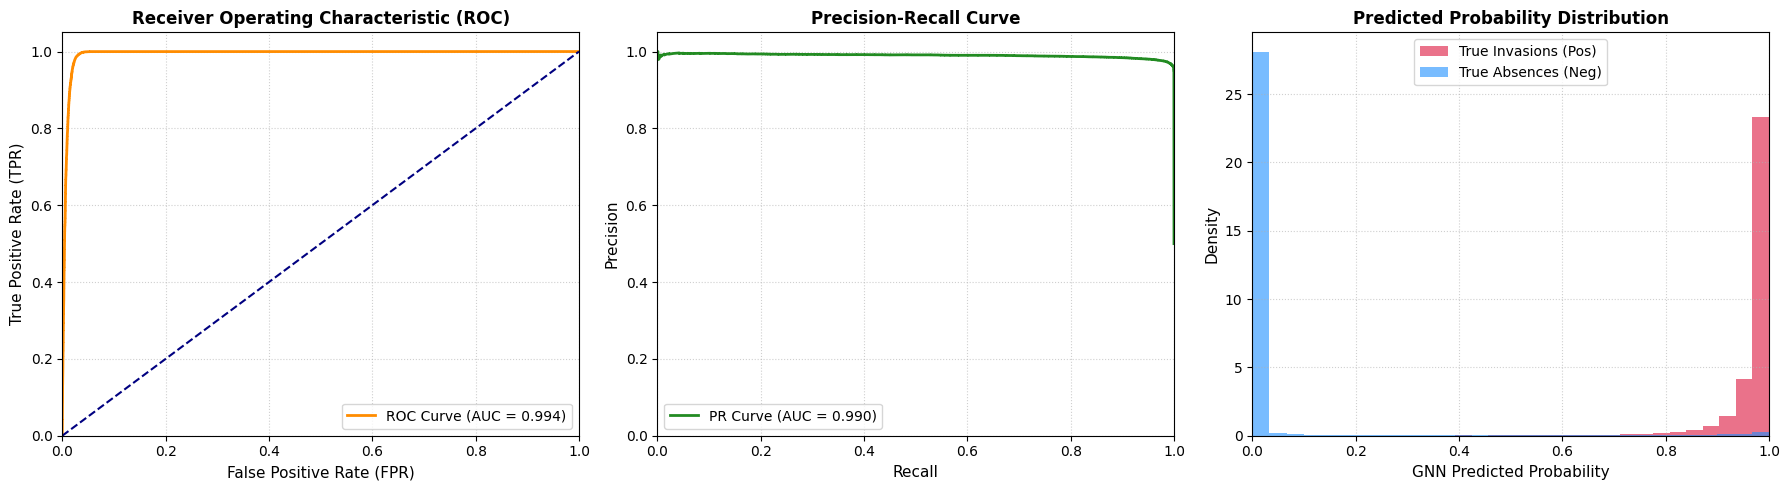


Final ROC-AUC: 0.9937
Final PR-AUC:  0.9898


In [28]:
# Evaluation and plotting function for performance metrics and diagnostic visualization

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import auc, precision_recall_curve, roc_curve


def evaluate_and_plot_performance(
    encoder,
    predictor,
    data,
    val_sp,
    val_co,
    val_neg_sp,
    val_neg_co
):
    """
    Computes core link prediction metrics and displays a 3-panel
    diagnostic dashboard to visually verify GNN classification performance.
    """

    encoder.eval()
    predictor.eval()

    with torch.no_grad():

        # 1. Generate network embeddings from the validation state
        emb = encoder(data.x_dict, data.edge_index_dict)

        # 2. Extract raw model outputs for both positive and negative validation edges
        val_pos_logits = predictor(
            emb['species'],
            emb['country'],
            val_sp,
            val_co
        )

        val_neg_logits = predictor(
            emb['species'],
            emb['country'],
            val_neg_sp,
            val_neg_co
        )

        # 3. Convert logits to probabilities
        pos_probs = torch.sigmoid(val_pos_logits).cpu().numpy()
        neg_probs = torch.sigmoid(val_neg_logits).cpu().numpy()

    # ------------------------------------------------------------------
    # BUILD GROUND TRUTH LABELS
    # ------------------------------------------------------------------
    y_true = np.concatenate([
        np.ones(len(pos_probs)),
        np.zeros(len(neg_probs))
    ])

    y_scores = np.concatenate([
        pos_probs,
        neg_probs
    ])

    # ------------------------------------------------------------------
    # ROC CURVE
    # ------------------------------------------------------------------
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # ------------------------------------------------------------------
    # PRECISION-RECALL CURVE
    # ------------------------------------------------------------------
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)

    # ------------------------------------------------------------------
    # TERMINAL REPORT
    # ------------------------------------------------------------------
    print("\n📊 GRAPH NEURAL NETWORK VERIFICATION REPORT")
    print("=" * 55)
    print(f"✅ ROC-AUC Score: {roc_auc:.4f}  (Target: > 0.80 for strong ranking)")
    print(f"✅ PR-AUC Score:  {pr_auc:.4f}  (Target: > 0.80 for low false-alarms)")
    print("=" * 55)
    print(
        f"ℹ️ True Invasion (Pos) Risk Range: "
        f"{pos_probs.min():.4f} to {pos_probs.max():.4f}"
    )
    print(
        f"ℹ️ True Absence  (Neg) Risk Range: "
        f"{neg_probs.min():.4f} to {neg_probs.max():.4f}"
    )

    # ------------------------------------------------------------------
    # MATPLOTLIB DASHBOARD
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ==============================================================
    # PLOT A: ROC CURVE
    # ==============================================================
    axes[0].plot(
        fpr,
        tpr,
        color="darkorange",
        lw=2,
        label=f"ROC Curve (AUC = {roc_auc:.3f})"
    )

    axes[0].plot(
        [0, 1],
        [0, 1],
        color="navy",
        lw=1.5,
        linestyle="--"
    )

    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel("False Positive Rate (FPR)", fontsize=11)
    axes[0].set_ylabel("True Positive Rate (TPR)", fontsize=11)
    axes[0].set_title(
        "Receiver Operating Characteristic (ROC)",
        fontsize=12,
        fontweight="bold"
    )
    axes[0].legend(loc="lower right", fontsize=10)
    axes[0].grid(True, linestyle=":", alpha=0.6)

    # ==============================================================
    # PLOT B: PRECISION-RECALL CURVE
    # ==============================================================
    axes[1].plot(
        recall,
        precision,
        color="forestgreen",
        lw=2,
        label=f"PR Curve (AUC = {pr_auc:.3f})"
    )

    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel("Recall", fontsize=11)
    axes[1].set_ylabel("Precision", fontsize=11)
    axes[1].set_title(
        "Precision-Recall Curve",
        fontsize=12,
        fontweight="bold"
    )
    axes[1].legend(loc="lower left", fontsize=10)
    axes[1].grid(True, linestyle=":", alpha=0.6)

    # ==============================================================
    # PLOT C: PROBABILITY DISTRIBUTIONS
    # ==============================================================
    axes[2].hist(
        pos_probs,
        bins=30,
        alpha=0.6,
        color="crimson",
        density=True,
        label="True Invasions (Pos)"
    )

    axes[2].hist(
        neg_probs,
        bins=30,
        alpha=0.6,
        color="dodgerblue",
        density=True,
        label="True Absences (Neg)"
    )

    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_xlabel("GNN Predicted Probability", fontsize=11)
    axes[2].set_ylabel("Density", fontsize=11)
    axes[2].set_title(
        "Predicted Probability Distribution",
        fontsize=12,
        fontweight="bold"
    )
    axes[2].legend(loc="upper center", fontsize=10)
    axes[2].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

    return roc_auc, pr_auc


# ------------------------------------------------------------------
# RUN VALIDATION DIAGNOSTIC
# ------------------------------------------------------------------
roc_auc, pr_auc = evaluate_and_plot_performance(
    encoder,
    predictor,
    data,
    val_sp,
    val_co,
    val_neg_sp,
    val_neg_co
)

print(f"\nFinal ROC-AUC: {roc_auc:.4f}")
print(f"Final PR-AUC:  {pr_auc:.4f}")

# 8. Validate data with GBIF backbone to only retain true absences

In [29]:
# ==============================================================================
# 8. GBIF VALIDATION — DIRECT ID LOOKUP (BULLETPROOF VERSION)
# ==============================================================================
def validate_horizon_threats_gbif(
    risk_df: pd.DataFrame,
    gbif_country_code: str,
    species_to_validate: int = 100,
    sleep_time: float = 0.2
) -> pd.DataFrame:
    """
    Validates GNN risk predictions by checking live GBIF occurrence counts
    directly via integer taxon keys. Bypasses text searching completely.
    Resolves missing name strings for network-only interaction partners.
    """
    if not gbif_country_code:
        print("⚠️ No GBIF country code provided. Skipping validation step.")
        return risk_df.head(species_to_validate)

    print(f"🔍 Validating GNN threats via direct GBIF IDs for country: '{gbif_country_code}'...")
    validated_records = []
    api_calls_made    = 0
    errors_hit        = 0
    discarded_present = 0

    with tqdm(total=species_to_validate, desc="Verified absent threats", unit="species") as pbar:
        for _, row in risk_df.iterrows():
            if len(validated_records) >= species_to_validate:
                print(f"\n🎯 Top {species_to_validate} verified horizon threats successfully secured!")
                break

            if api_calls_made > 0:
                time.sleep(sleep_time)

            api_calls_made += 1
            
            # Extract the absolute, pre-verified integer key from your GNN graph node mapping
            taxon_key = int(row['gbif_id'])
            current_name = str(row['taxon_name'])

            try:
                # 1. If the name is an unresolved ID string, fetch its true name directly by its ID
                if current_name.startswith("GBIF:"):
                    usage = gbif_species.name_usage(key=taxon_key)
                    resolved_name = usage.get('scientificName', f"Unresolved ID: {taxon_key}")
                else:
                    resolved_name = current_name

                # 2. Query live occurrences directly using the precise integer key
                # Setting limit=0 returns only the record count, maximizing API performance
                res = occurrences.search(taxonKey=taxon_key, country=gbif_country_code, limit=0)
                occurrence_count = res.get('count', 0)

                # 3. Filter: Keep the species only if its live count in the target country is zero
                if occurrence_count == 0:
                    new_row = row.to_dict()  # Preserves your gnn_invasion_probability
                    new_row['taxon_name']            = resolved_name
                    new_row['gbif_matched_name']     = resolved_name
                    new_row['gbif_occurrence_count'] = occurrence_count
                    new_row['gbif_taxon_key']        = taxon_key
                    validated_records.append(new_row)
                    pbar.update(1)
                else:
                    discarded_present += 1

                pbar.set_postfix({
                    'API calls': api_calls_made,
                    'Present in Country': discarded_present,
                    'Errors': errors_hit
                })

            except Exception as e:
                errors_hit += 1
                time.sleep(sleep_time * 5)
                
                # If a network timeout occurs, log the error details while retaining the record
                err_row = row.to_dict()
                err_row['gbif_matched_name']     = f"FETCH ERROR: {str(e)[:40]}"
                err_row['gbif_occurrence_count'] = -1
                err_row['gbif_taxon_key']        = taxon_key
                validated_records.append(err_row)
                pbar.update(1)
                
                pbar.set_postfix({
                    'API calls': api_calls_made,
                    'Present in Country': discarded_present,
                    'Errors': errors_hit
                })

    return pd.DataFrame(validated_records).reset_index(drop=True)

# 9. Example for invasion risk predictions in Belgium

In [30]:
# ==============================================================================
# RUN — BELGIUM
# ==============================================================================
# Step 1: GNN ranks all candidate species by invasion probability
belgium_gnn_rankings = execute_gnn_horizon_scan('Belgium', top_n=500)

# Step 2: GBIF confirms which of those are genuinely not yet present in Belgium
belgium_validated = validate_horizon_threats_gbif(
    belgium_gnn_rankings,
    gbif_country_code='BE',
    species_to_validate=100,
    sleep_time=0.2
)

belgium_validated.head(20)

✅ GNN scan complete — 500 candidates ranked for GBIF validation.
🔍 Validating GNN threats via direct GBIF IDs for country: 'BE'...


Verified absent threats:   0%|          | 0/100 [00:00<?, ?species/s]


🎯 Top 100 verified horizon threats successfully secured!


,gbif_id,taxon_name,gnn_invasion_probability,gbif_matched_name,gbif_occurrence_count,gbif_taxon_key
0,5109850,Spodoptera eridania,0.998619,Spodoptera eridania,0,5109850
1,2374540,Terapon puta,0.998134,Terapon puta,0,2374540
2,9631834,Chenopodium urbicum,0.998011,Chenopodium urbicum,0,9631834
3,3083565,Cycloloma atriplicifolia,0.997983,Cycloloma atriplicifolia,0,3083565
4,3097185,Tolpis umbellata,0.997926,Tolpis umbellata,0,3097185
5,4933339,Orobanche krylovii G.Beck,0.997908,Orobanche krylovii G.Beck,0,4933339
6,2386919,Callionymus filamentosus,0.997887,Callionymus filamentosus,0,2386919
7,8004571,Clinopodium vulgare arundanum,0.997876,Clinopodium vulgare arundanum,0,8004571
8,2421766,Gastrophryne carolinensis,0.997817,Gastrophryne carolinensis,0,2421766
9,7454879,Karenia mikimotoi,0.997799,Karenia mikimotoi,0,7454879


# 10. Explain the rankings by looking at local topology of the GNN

In [ ]:
import pandas as pd
import numpy as np
import torch

def explain_topology_prediction(target_species_name: str, target_country_name: str, top_k_neighbors: int = 10):
    """
    Explains a GNN prediction by finding which historical connections in the graph
    contributed the most to the candidate species' high embedding alignment.
    Filters out uninformative self-loops.
    """
    name_to_id_dict = {str(v): k for k, v in id_to_name.items()}

    if target_species_name in name_to_id_dict:
        sp_id = name_to_id_dict[target_species_name]
    else:
        try:
            clean_id = int(str(target_species_name).replace("GBIF:", "").strip())
            sp_id = clean_id if clean_id in sp_to_idx else None
        except ValueError:
            sp_id = None

    if sp_id is None or sp_id not in sp_to_idx:
        print(f"❌ Could not find indexed species matching identifier '{target_species_name}'")
        return

    sp_idx = sp_to_idx[sp_id]
    co_idx = co_to_idx[target_country_name]
    
    encoder.eval()
    predictor.eval()
    
    with torch.no_grad():
        baseline_embeddings = encoder(data.x_dict, data.edge_index_dict)
        baseline_logits = predictor(
            baseline_embeddings['species'], baseline_embeddings['country'], 
            torch.tensor([sp_idx]), torch.tensor([co_idx])
        )
        baseline_score = torch.sigmoid(baseline_logits).item()
        
    print(f"🕵️‍♂️ Analyzing Horizon Threat Profile for: {id_to_name.get(sp_id, target_species_name)}")
    print(f"🌍 Target Country: {target_country_name} | Baseline GNN Risk: {baseline_score:.4f}")
    print("-" * 75)
    
    important_relationships = []
    
    for edge_type in ['resource', 'mutualism', 'competition', 'enemy']:
        if ('species', edge_type, 'species') not in data.edge_index_dict:
            continue
            
        edge_index = data['species', edge_type, 'species'].edge_index
        if edge_index.numel() == 0:
            continue 
        
        src_mask = (edge_index == sp_idx)
        tgt_mask = (edge_index == sp_idx)
        
        neighbors = torch.cat([edge_index[src_mask], edge_index[tgt_mask]]).cpu().numpy()
        neighbors = np.unique(neighbors) 
        
        for neighbor_idx in neighbors:
            neighbor_idx = int(neighbor_idx)
            
            # 🔥 FIX: Stop species self-referencing
            if neighbor_idx == sp_idx:
                continue
                
            neighbor_gbif_id = idx_to_sp[neighbor_idx]
            neighbor_name = id_to_name.get(neighbor_gbif_id, f"Unresolved GBIF:{neighbor_gbif_id}")
            
            with torch.no_grad():
                sp_vector = baseline_embeddings['species'][sp_idx]
                neigh_vector = baseline_embeddings['species'][neighbor_idx]
                alignment = torch.cosine_similarity(sp_vector.unsqueeze(0), neigh_vector.unsqueeze(0)).item()
                
            important_relationships.append({
                'Neighbor Name': neighbor_name,
                'Relationship Lane': edge_type,
                'Network Alignment Strength': alignment
            })
            
    df_importance = pd.DataFrame(important_relationships)
    if df_importance.empty:
        print("ℹ️ This species is an isolated node; its risk is driven by broad macro-demographics.")
        return
        
    df_importance = df_importance.sort_values('Network Alignment Strength', ascending=False).head(top_k_neighbors)
    
    print(f"🔥 TOP {len(df_importance)} ECOLOGICAL DRIVERS GENERATING THIS RISK SCORE:")
    display(df_importance.reset_index(drop=True))

In [ ]:
# ==============================================================================
# 🔥 EXECUTE THE TOPOLOGICAL EXPLAINER ON YOUR TOP BELGIUM THREAT
# ==============================================================================

# 1. Automatically pluck the #1 ranked threat verified as absent from Belgium
top_threat_name = belgium_validated.iloc["taxon_name"]
top_threat_prob = belgium_validated.iloc["gnn_invasion_probability"]

print(
    f"🎯 Target Species Identified: '{top_threat_name}' (GNN Predicted Probability: {top_threat_prob:.4f})"
)

# 2. Run the multi-level network alignment breakdown
explain_topology_prediction(
    target_species_name=top_threat_name,
    target_country_name="Belgium",
    top_k_neighbors=10,  # Show the top 10 most influential structural connections
)

🎯 Plucked Top Verified Threat: 'Spodoptera eridania' (GNN Risk: 0.9986)
🕵️‍♂️ Analyzing Horizon Threat Profile for: Spodoptera eridania
🌍 Target Country: Belgium | Baseline GNN Risk: 0.9986
---------------------------------------------------------------------------
ℹ️ This species is an isolated node; its risk is driven by broad macro-demographics.


# 11. Plot the graphs (meta and local) for visualization purposes

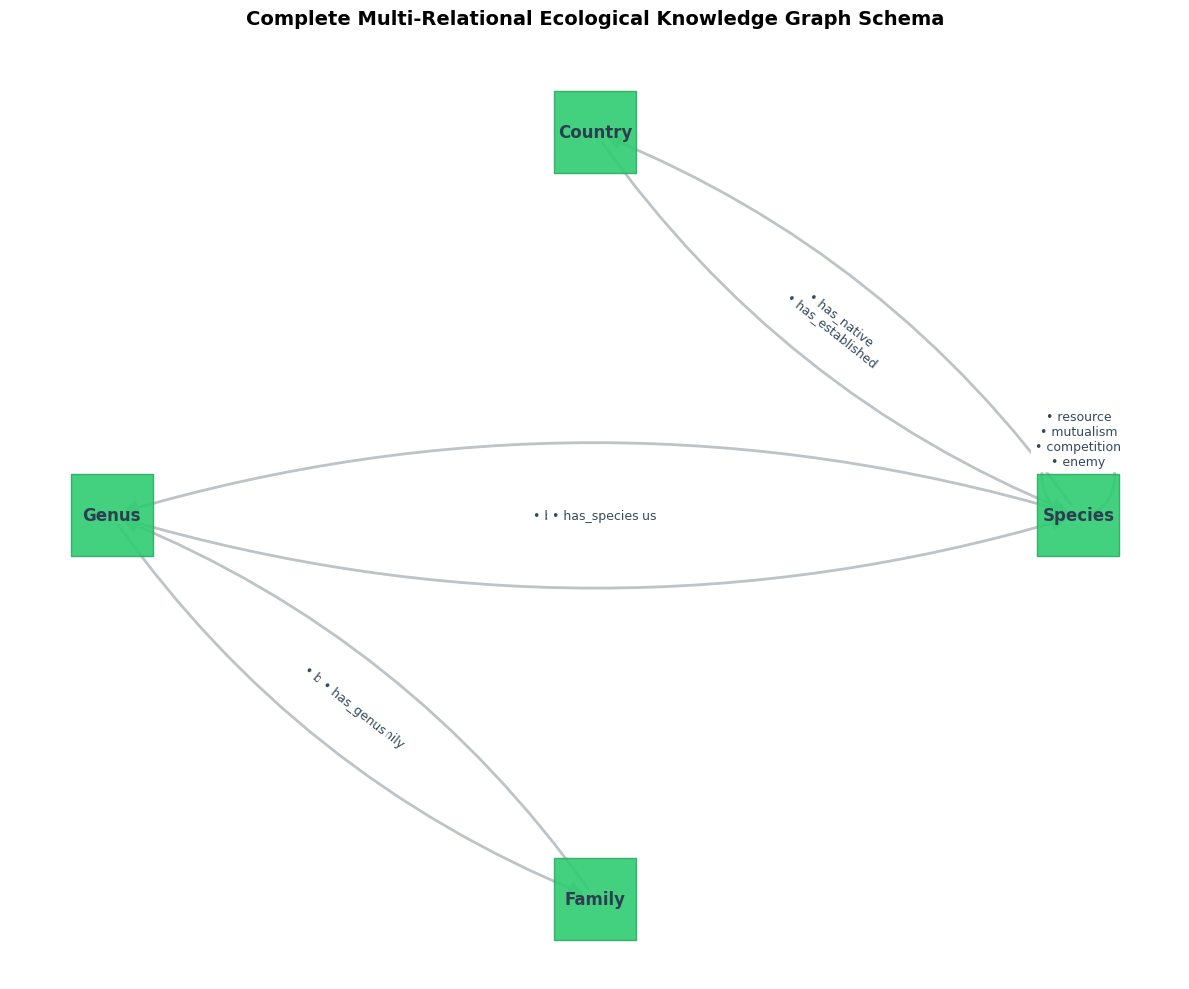

In [7]:
import matplotlib.pyplot as plt
import networkx as nx


def plot_metagraph_schema_fixed(pyg_data):
    """Plots the high-level structural schema of a HeteroData object,

    safely consolidating multi-relational self-loops and parallel pathways.
    """
    G = nx.DiGraph()
    node_types, edge_types = pyg_data.metadata()

    # 1. Group relationships by unique node pairs to bypass the DiGraph overwrite trap
    edge_groups = {}
    for src, rel, tgt in edge_types:
        u = src.capitalize()
        v = tgt.capitalize()
        if (u, v) not in edge_groups:
            edge_groups[(u, v)] = []
        edge_groups[(u, v)].append(rel)

    # 2. Add edges to NetworkX with consolidated multiline labels
    for (u, v), rel_list in edge_groups.items():
        # Clean up labels for a neat presentation
        display_label = "\n".join([f"• {r}" for r in rel_list])
        G.add_edge(u, v, label=display_label)

    # 3. Setup visual canvas layout
    plt.figure(figsize=(12, 10))

    # Using circular layout keeps the hierarchy clean across Species, Genus, Family, Country
    pos = nx.circular_layout(G)

    # Draw structural blocks
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=3500,
        node_color="#2ecc71",
        edgecolors="#27ae60",
        node_shape="s",
        alpha=0.9,
    )
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=12,
        font_weight="bold",
        font_color="#2c3e50",
    )

    # Draw connection highways with a subtle arc to separate forward/backward paths
    nx.draw_networkx_edges(
        G,
        pos,
        arrowstyle="-|>",
        arrowsize=20,
        edge_color="#bdc3c7",
        width=2,
        connectionstyle="arc3,rad=0.15",
    )

    # 4. Render the unified relationship labels
    edge_labels = {(u, v): d["label"] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, font_size=9, font_color="#34495e"
    )

    plt.title(
        "Complete Multi-Relational Ecological Knowledge Graph Schema",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# ==============================================================================
# 🔥 RUN THE FIXED PLOT
# ==============================================================================
plot_metagraph_schema_fixed(data)

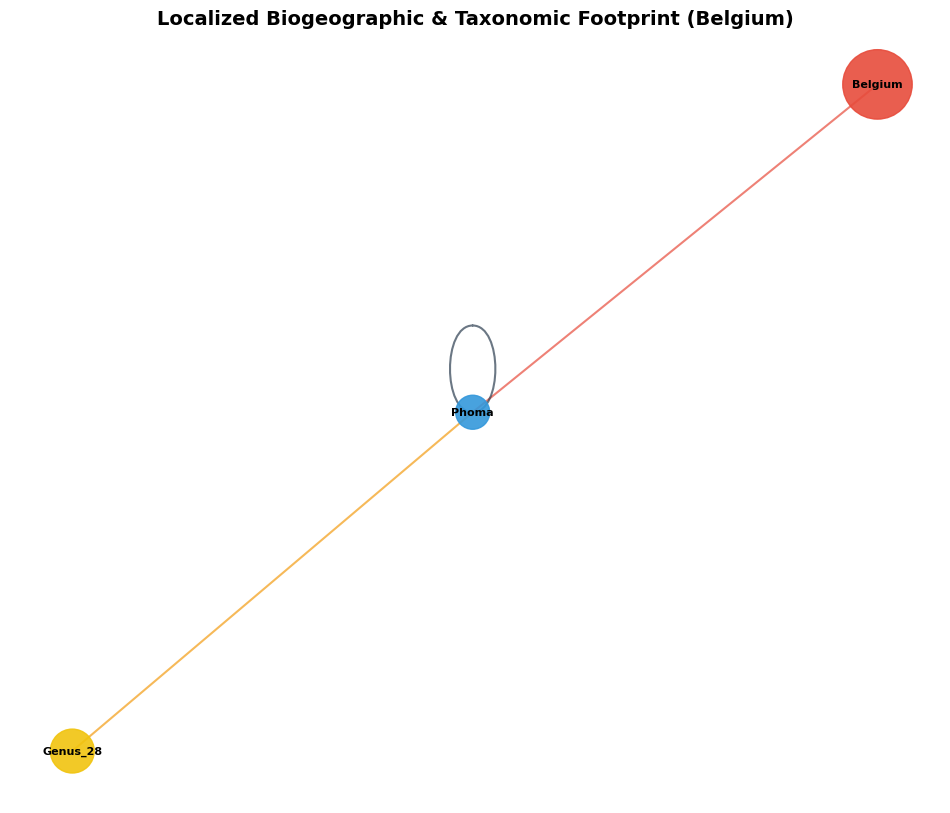

In [22]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch


def plot_local_ecosystem(target_country_name: str, max_species_to_show: int = 8):
    """Slices a safe, readable local subgraph around a target country

    and displays its immediate taxonomic and biotic network.
    """
    if target_country_name not in co_to_idx:
        print(f"❌ Country '{target_country_name}' not found.")
        return

    co_idx = co_to_idx[target_country_name]
    G = nx.Graph()

    # Add the target country node center-stage
    G.add_node(target_country_name, type="country")

    # 1. Harvest established alien species index numbers for this country
    est_edges = data["species", "established_in", "country"].edge_index

    # ✅ FIX 1: Explicitly target Row 1 (countries) to find matches
    mask = est_edges == co_idx
    # Pull the corresponding elements from Row 0 (species)
    local_sp_indices = est_edges[mask].cpu().numpy()

    # Cap the species count to keep the layout highly readable
    if len(local_sp_indices) > max_species_to_show:
        local_sp_indices = np.random.choice(
            local_sp_indices, max_species_to_show, replace=False
        )

    # 2. Trace connections for the selected subset of local species
    for sp_idx in local_sp_indices:
        sp_idx = int(sp_idx)
        sp_gbif_id = idx_to_sp[sp_idx]
        sp_name = id_to_name.get(sp_gbif_id, f"Species ID:{sp_gbif_id}")

        G.add_node(sp_name, type="species")
        G.add_edge(target_country_name, sp_name, rel="established_in")

        # Trace taxonomic lineage upward (belongs_to_genus)
        gen_edges = data["species", "belongs_to_genus", "genus"].edge_index

        # ✅ FIX 2: Explicitly target Row 0 (species) to match our current item
        gen_mask = gen_edges == sp_idx
        if torch.any(gen_mask):
            # Isolate the corresponding genus entry out of Row 1 safely
            gen_idx = int(gen_edges[gen_mask].item())
            gen_label = f"Genus_{gen_idx}"
            G.add_node(gen_label, type="genus")
            G.add_edge(sp_name, gen_label, rel="genus_hierarchy")

        # Trace a tiny snapshot of localized biotic pressures (e.g., enemy lane)
        enemy_edges = data["species", "enemy", "species"].edge_index

        # ✅ FIX 3: Explicitly target Row 0 (source species) to look for interaction lanes
        enemy_mask = enemy_edges == sp_idx
        linked_species = enemy_edges[enemy_mask].cpu().numpy()

        for counter, linked_sp in enumerate(linked_species):
            if counter >= 2:
                break  # Only show up to 2 predators/prey to keep visualization clean
            linked_name = id_to_name.get(
                idx_to_sp[int(linked_sp)], f"Species ID:{linked_sp}"
            )
            G.add_node(linked_name, type="species")
            G.add_edge(sp_name, linked_name, rel="enemy_pressure")

    # 3. Design custom color profiles per node category
    color_map = []
    size_map = []
    for node, attrs in G.nodes(data=True):
        n_type = attrs.get("type", "species")
        if n_type == "country":
            color_map.append("#e74c3c")  # Bright Crimson Red
            size_map.append(2500)
        elif n_type == "genus":
            color_map.append("#f1c40f")  # Yellow
            size_map.append(1000)
        else:
            color_map.append("#3498db")  # Blue for Species nodes
            size_map.append(600)

    # 4. Render Dashboard Visualization
    plt.figure(figsize=(12, 10))
    pos = nx.kamada_kawai_layout(
        G
    )  # Yields clean spacing for bipartite graphs

    nx.draw_networkx_nodes(
        G, pos, node_color=color_map, node_size=size_map, alpha=0.9
    )
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")

    # Draw distinct edge lane types
    edges_by_type = {}
    for u, v, d in G.edges(data=True):
        rel = d["rel"]
        edges_by_type.setdefault(rel, []).append((u, v))

    edge_colors = {
        "established_in": "#e74c3c",
        "genus_hierarchy": "#f39c12",
        "enemy_pressure": "#2c3e50",
    }
    for rel_type, edge_list in edges_by_type.items():
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=edge_list,
            edge_color=edge_colors.get(rel_type, "#bdc3c7"),
            width=1.5,
            alpha=0.7,
        )

    plt.title(
        f"Localized Biogeographic & Taxonomic Footprint ({target_country_name})",
        fontsize=14,
        fontweight="bold",
    )
    plt.axis("off")
    plt.show()


# ==============================================================================
# 🔥 EXECUTE REPAIRED GRAPH VISUALIZATION
# ==============================================================================
plot_local_ecosystem(target_country_name="Belgium", max_species_to_show=15)

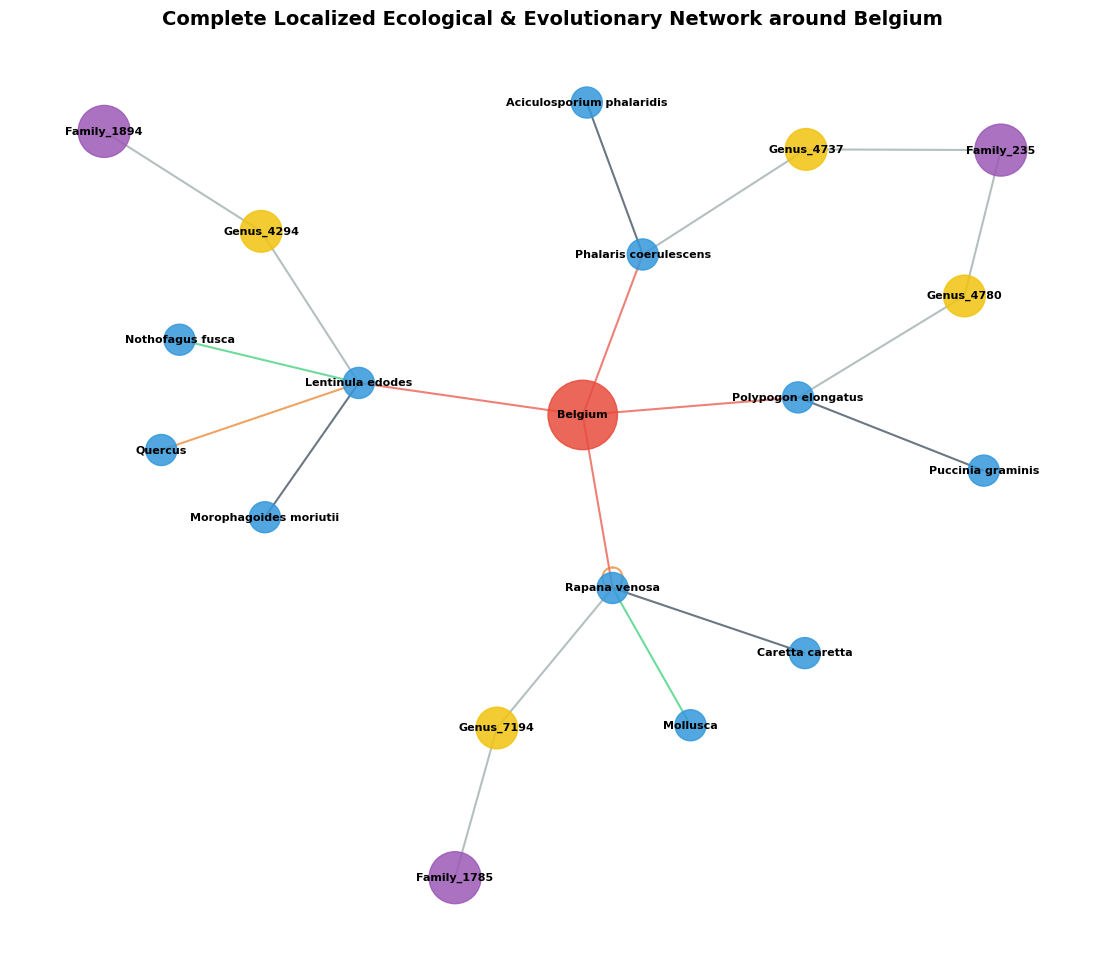

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D


def plot_complete_local_ecosystem(
    target_country_name: str,
    max_species_to_show: int = 5,
):

    if target_country_name not in co_to_idx:
        print(f"❌ Country '{target_country_name}' not found.")
        return

    co_idx = co_to_idx[target_country_name]

    G = nx.Graph()

    G.add_node(
        target_country_name,
        type="country",
    )

    # ==================================================
    # 1. Gather established species
    # ==================================================

    est_edges = data[
        "species",
        "established_in",
        "country",
    ].edge_index

    mask = est_edges[1] == co_idx

    local_sp_indices = (
        est_edges[0][mask]
        .cpu()
        .numpy()
    )

    if len(local_sp_indices) > max_species_to_show:

        local_sp_indices = np.random.choice(
            local_sp_indices,
            max_species_to_show,
            replace=False,
        )

    # ==================================================
    # 2. Build ecological network
    # ==================================================

    for sp_idx in local_sp_indices:

        sp_idx = int(sp_idx)

        sp_gbif_id = idx_to_sp[sp_idx]

        sp_name = id_to_name.get(
            sp_gbif_id,
            f"Species ID:{sp_gbif_id}",
        )

        G.add_node(
            sp_name,
            type="species",
        )

        G.add_edge(
            target_country_name,
            sp_name,
            rel="established_in",
            weight=1,
        )

        # ----------------------------------------------
        # Taxonomic cascade
        # ----------------------------------------------

        gen_edges = data[
            "species",
            "belongs_to_genus",
            "genus",
        ].edge_index

        gen_mask = gen_edges[0] == sp_idx

        if gen_mask.any():

            gen_idx = int(
                gen_edges[1][gen_mask][0].item()
            )

            gen_label = f"Genus_{gen_idx}"

            G.add_node(
                gen_label,
                type="genus",
            )

            G.add_edge(
                sp_name,
                gen_label,
                rel="taxonomy",
                weight=1,
            )

            fam_edges = data[
                "genus",
                "belongs_to_family",
                "family",
            ].edge_index

            fam_mask = fam_edges[0] == gen_idx

            if fam_mask.any():

                fam_idx = int(
                    fam_edges[1][fam_mask][0].item()
                )

                fam_label = f"Family_{fam_idx}"

                G.add_node(
                    fam_label,
                    type="family",
                )

                G.add_edge(
                    gen_label,
                    fam_label,
                    rel="taxonomy",
                    weight=1,
                )

        # ----------------------------------------------
        # Species interactions
        # ----------------------------------------------

        for lane in [
            "resource",
            "mutualism",
            "enemy",
        ]:

            edge_key = (
                "species",
                lane,
                "species",
            )

            if edge_key not in data.edge_index_dict:
                continue

            int_edges = data[edge_key].edge_index

            src_mask = int_edges[0] == sp_idx

            linked_species = (
                int_edges[1][src_mask]
                .cpu()
                .numpy()
            )

            # Keep only first partner to avoid clutter
            for counter, linked_sp in enumerate(linked_species):

                if counter >= 1:
                    break

                linked_sp = int(linked_sp)

                linked_name = id_to_name.get(
                    idx_to_sp[linked_sp],
                    f"Species ID:{linked_sp}",
                )

                G.add_node(
                    linked_name,
                    type="species",
                )

                if G.has_edge(sp_name, linked_name):

                    G[sp_name][linked_name]["weight"] += 1

                else:

                    G.add_edge(
                        sp_name,
                        linked_name,
                        rel=lane,
                        weight=1,
                    )

    # ==================================================
    # 3. Node styling
    # ==================================================

    color_map = []
    size_map = []

    for _, attrs in G.nodes(data=True):

        n_type = attrs.get(
            "type",
            "species",
        )

        if n_type == "country":

            color_map.append("#e74c3c")
            size_map.append(2500)

        elif n_type == "family":

            color_map.append("#9b59b6")
            size_map.append(1400)

        elif n_type == "genus":

            color_map.append("#f1c40f")
            size_map.append(900)

        else:

            color_map.append("#3498db")
            size_map.append(500)

    # ==================================================
    # 4. Plot
    # ==================================================

    plt.figure(figsize=(20, 12))

    pos = nx.kamada_kawai_layout(G)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=color_map,
        node_size=size_map,
        alpha=0.85,
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=8,
        font_weight="bold",
    )

    # ==================================================
    # Edge grouping
    # ==================================================

    edges_by_type = {}

    for u, v, d in G.edges(data=True):

        rel = d["rel"]

        edges_by_type.setdefault(
            rel,
            [],
        ).append((u, v))

    edge_styles = {
        "established_in": "solid",
        "taxonomy": "dotted",
        "resource": "dashed",
        "mutualism": "dashdot",
        "enemy": (0, (5, 1)),
    }

    for rel_type, edge_list in edges_by_type.items():

        widths = []

        for u, v in edge_list:

            weight = G[u][v].get(
                "weight",
                1,
            )

            widths.append(
                1 + np.log1p(weight)
            )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=edge_list,
            edge_color="black",
            style=edge_styles.get(
                rel_type,
                "solid",
            ),
            width=widths,
            alpha=0.8,
        )

    # ==================================================
    # Node legend
    # ==================================================

    node_legend = [

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label="Country",
            markerfacecolor="#e74c3c",
            markersize=14,
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label="Family",
            markerfacecolor="#9b59b6",
            markersize=12,
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label="Genus",
            markerfacecolor="#f1c40f",
            markersize=10,
        ),

        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label="Species",
            markerfacecolor="#3498db",
            markersize=8,
        ),
    ]

    # ==================================================
    # Relationship legend
    # ==================================================

    edge_legend = [

        Line2D(
            [0], [0],
            color="black",
            lw=2.5,
            linestyle="solid",
            label="Established in Country",
        ),

        Line2D(
            [0], [0],
            color="black",
            lw=2.5,
            linestyle="dotted",
            label="Taxonomic Link",
        ),

        Line2D(
            [0], [0],
            color="black",
            lw=2.5,
            linestyle="dashed",
            label="Resource Interaction",
        ),

        Line2D(
            [0], [0],
            color="black",
            lw=2.5,
            linestyle="dashdot",
            label="Mutualism Interaction",
        ),

        Line2D(
            [0], [0],
            color="black",
            lw=2.5,
            linestyle=(0, (5, 1)),
            label="Enemy Interaction",
        ),
    ]

    # ==================================================
    # Weight legend
    # ==================================================

    weight_legend = [

        Line2D(
            [0], [0],
            color="black",
            lw=1,
            label="Weak",
        ),

        Line2D(
            [0], [0],
            color="black",
            lw=3,
            label="Moderate",
        ),

        Line2D(
            [0], [0],
            color="black",
            lw=6,
            label="Strong",
        ),
    ]

    legend1 = plt.legend(
        handles=node_legend,
        title="Node Types",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().add_artist(legend1)

    legend2 = plt.legend(
        handles=edge_legend,
        title="Relationship Types",
        loc="upper left",
        bbox_to_anchor=(0.98, 0.60),
    )

    plt.gca().add_artist(legend2)

    plt.legend(
        handles=weight_legend,
        title="Connection Strength",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.25),
    )

    plt.title(
        f"Localized Ecological & Evolutionary Network around {target_country_name}",
        fontsize=14,
        fontweight="bold",
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 🔥 RUN THE EXPANDED LOCAL LOOKUP
# ==============================================================================
plot_complete_local_ecosystem(target_country_name="Belgium", max_species_to_show=10)